# pdfplumber — Model Comparison
F1 score per label and standard confusion matrix for all available models.
**Samples evaluated:** 3–10 (samples 1 & 2 excluded)

In [1]:
MODELS = [
    ("llama3.1:8b",  "llama3.1-8b_pdfplumber_whole_doc"),
    ("llama3.3:70b", "llama3.3-70b_pdfplumber_whole_doc"),
    ("gemma4:e4b",   "gemma4-e4b_pdfplumber_whole_doc"),
]
EXCLUDE = [1, 2]

In [2]:
from dmpbridge.evaluation.evaluate import load_method, compute_f1_rows, confusion_matrix_df
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

results = {}
for display_name, tag in MODELS:
    df, conf, errs = load_method(tag, exclude=EXCLUDE)
    if df is None:
        print(f'{display_name:15s} : no data yet')
        continue
    tc, tn = int(df['correct'].sum()), int(df['total'].sum())
    results[display_name] = {'df': df, 'conf': conf, 'tag': tag}
    print(f'{display_name:15s} : {tc}/{tn}  ({tc/tn*100:.1f}% block accuracy)')

llama3.1:8b     : 387/488  (79.3% block accuracy)


llama3.3:70b    : 313/361  (86.7% block accuracy)
gemma4:e4b      : no data yet


## F1 Score per Label

Label                        llama3.1:8b   llama3.3:70b
-------------------------------------------------------
title                              94.1%          92.3%
section.title                      77.1%          68.1%
section.description                65.1%          56.3%
question.text                       2.5%           0.0%
answer.text                        88.7%          93.4%


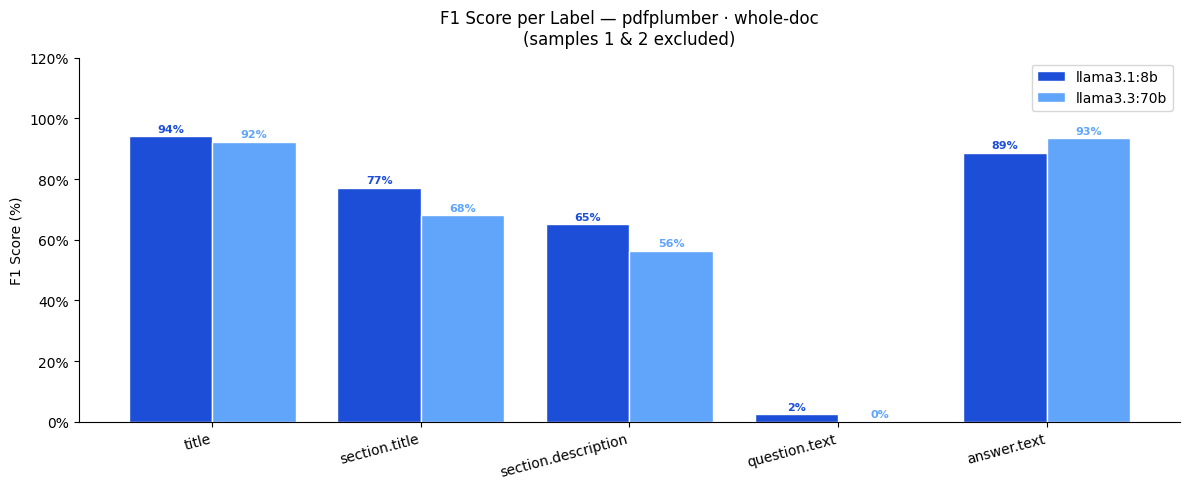

In [3]:
COLORS = ['#1d4ed8', '#60a5fa', '#34d399']

f1_data = {}
for name, res in results.items():
    f1_data[name] = compute_f1_rows(res['conf']).set_index('label')['f1']

df_f1 = pd.DataFrame(f1_data) * 100

# Table
print(f"{'Label':<25}" + ''.join(f'{n:>15}' for n in df_f1.columns))
print('-' * (25 + 15 * len(df_f1.columns)))
for label, row in df_f1.iterrows():
    print(f'{label:<25}' + ''.join(f'{v:>14.1f}%' for v in row))

# Bar chart
n_models = len(df_f1.columns)
n_labels = len(df_f1)
w = 0.8 / n_models
xi = range(n_labels)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(df_f1.columns, COLORS[:n_models])):
    offset = (i - n_models / 2 + 0.5) * w
    bars = ax.bar([x + offset for x in xi], df_f1[name], width=w,
                  label=name, color=color, edgecolor='white')
    for bar, val in zip(bars, df_f1[name]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8,
                fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(df_f1.index, rotation=15, ha='right')
ax.set_ylim(0, 120)
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 Score per Label — pdfplumber · whole-doc\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Confusion Matrix per Model
Rows = true label · Columns = predicted label

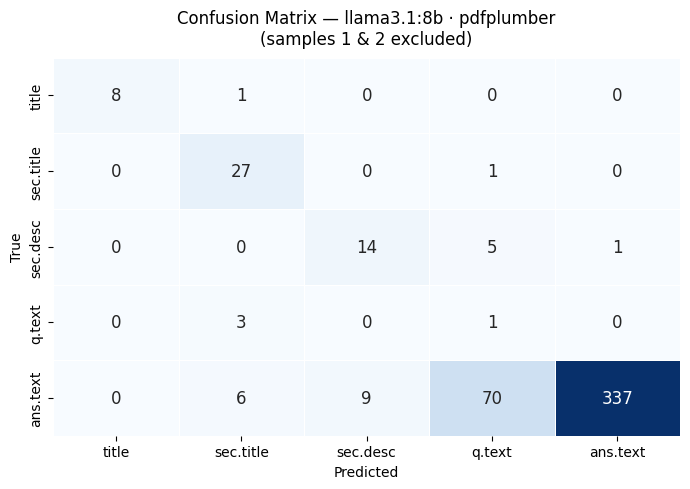

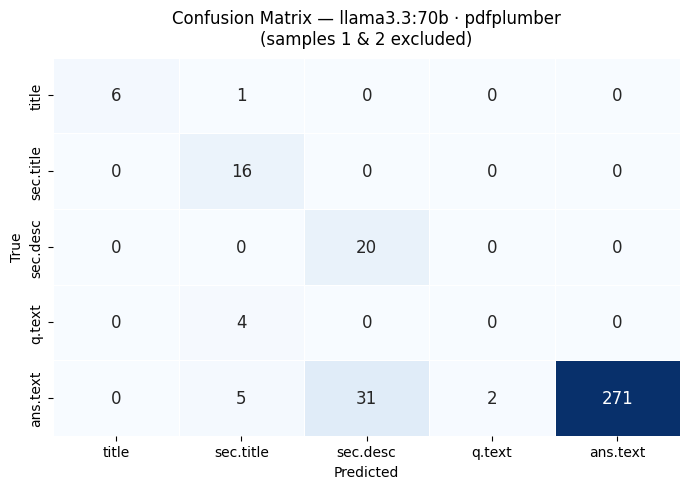

In [4]:
for name, res in results.items():
    mat = confusion_matrix_df(res['conf']).drop(columns=['missed'])

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, linecolor='white',
                ax=ax, cbar=False, annot_kws={'size': 12})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {name} · pdfplumber\n(samples 1 & 2 excluded)', pad=10)
    plt.tight_layout()
    plt.show()